开始绘制边...
开始绘制边...
原始网格: 8个顶点, 12条边
细分网格: 64个网格点, 189条边
特殊标记的边: 12条 (红色虚线)


C:\Users\31717\AppData\Local\Temp\ipykernel_23488\2311204895.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


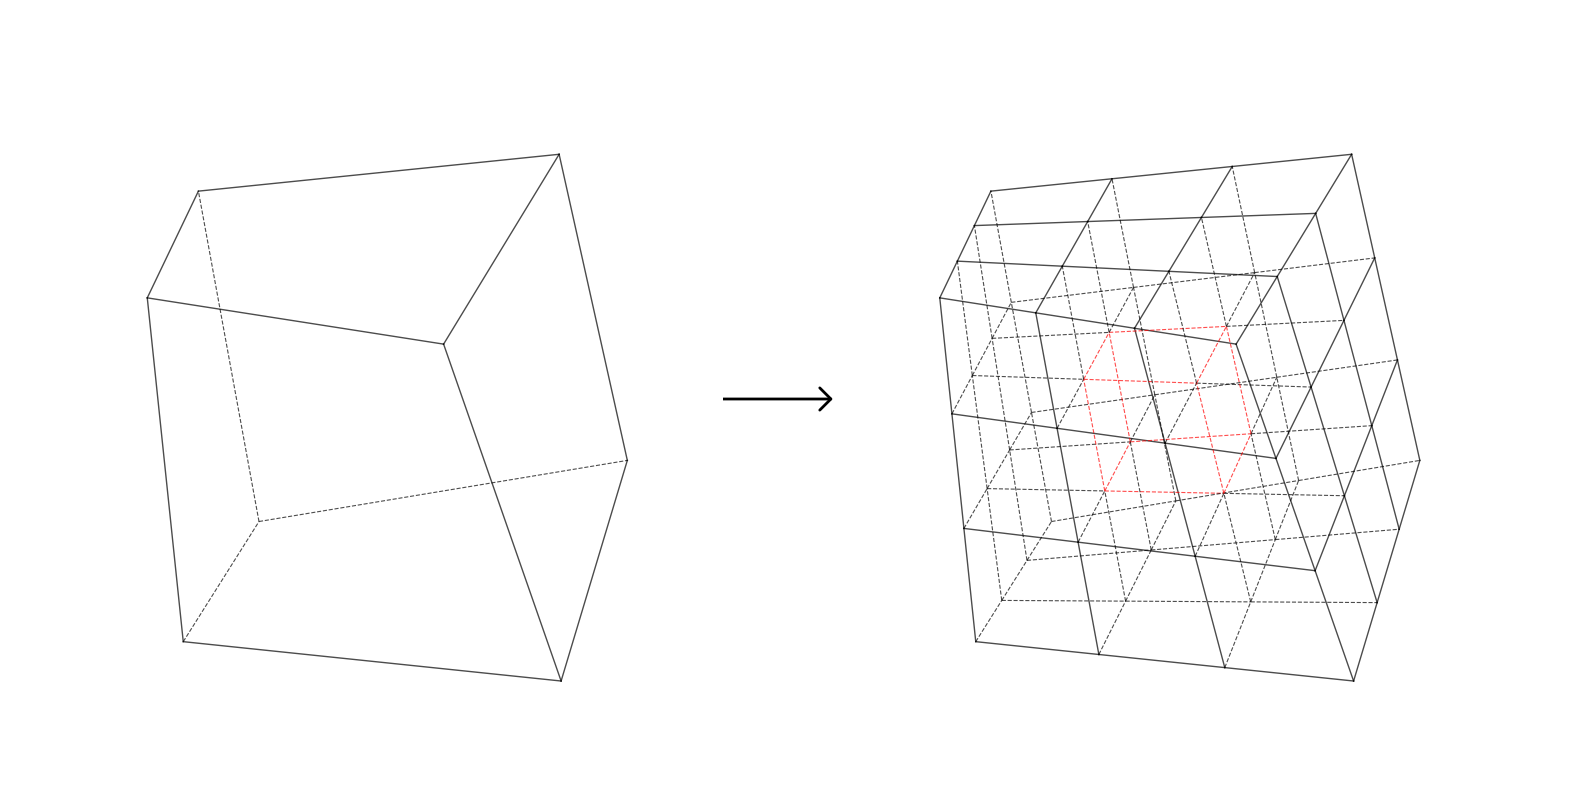

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

def trilinear_interpolation(p000, p001, p010, p011, p100, p101, p110, p111, u, v, w):
    return (1-u)*(1-v)*(1-w)*p000 + (1-u)*(1-v)*w*p001 + \
           (1-u)*v*(1-w)*p010 + (1-u)*v*w*p011 + \
           u*(1-v)*(1-w)*p100 + u*(1-v)*w*p101 + \
           u*v*(1-w)*p110 + u*v*w*p111

# 原始顶点
vertices = {
    (0,0,0): np.array([1.000, 0.000, 0.000]),
    (0,0,1): np.array([0.000, 0.777, 6.000]),
    (0,1,0): np.array([0.839, 2.000, 0.072]),
    (0,1,1): np.array([-0.619, 2.768, 5.979]),
    (1,0,0): np.array([7.000, 0.000, 0.798]),
    (1,0,1): np.array([5.000, 0.245, 6.796]),
    (1,1,0): np.array([5.839, 4.000, 0.285]),
    (1,1,1): np.array([4.381, 4.356, 6.202])
}
# === 创建图形和子图 ===
fig = plt.figure(figsize=(16, 8))

# 左子图：原始网格
ax_original = fig.add_subplot(121, projection='3d')
ax_original.view_init(elev=30, azim=-70)

# 右子图：细分网格
ax_subdivided = fig.add_subplot(122, projection='3d')
ax_subdivided.view_init(elev=30, azim=-70)
# 细分参数
n_u, n_v, n_w = 1, 1, 1
num_u, num_v, num_w = n_u+1, n_v+1, n_w+1

# === 第1步：生成所有细分点 ===
points = []  # 所有点的坐标列表
index_map = {}  # 逻辑索引到列表索引的映射

for iu in range(num_u):
    u = iu / n_u
    for iv in range(num_v):
        v = iv / n_v
        for iw in range(num_w):
            w = iw / n_w
            pt = trilinear_interpolation(
                vertices[(0,0,0)], vertices[(0,0,1)],
                vertices[(0,1,0)], vertices[(0,1,1)],
                vertices[(1,0,0)], vertices[(1,0,1)],
                vertices[(1,1,0)], vertices[(1,1,1)], u, v, w)
            points.append(pt)
            index_map[(iu, iv, iw)] = len(points)-1

# === 第2步：为每条边创建变量名 ===
# 命名规则：边_起点逻辑坐标_终点逻辑坐标
# 例如：edge_000_100 表示从 (iu,iv,iw)=(0,0,0) 到 (1,0,0) 的边

# 收集所有边（避免重复）
edges_to_draw = []

# === 第3步：绘制 ===

# u方向的边（x方向）
for iv in range(num_v):
    for iw in range(num_w):
        for iu in range(num_u-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu+1, iv, iw)]
            if iv==0 or iw==n_w :
                ax_original.plot([points[idx1][0], points[idx2][0]], [points[idx1][1], points[idx2][1]], [points[idx1][2], points[idx2][2]], 
            color='black', linestyle='-', linewidth=1, alpha=0.7)
            else:
                edges_to_draw.append((f'edge_u_{iu}{iv}{iw}_{iu+1}{iv}{iw}', idx1, idx2))
            

# v方向的边（y方向）
for iu in range(num_u):
    for iw in range(num_w):
        for iv in range(num_v-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu, iv+1, iw)]
            if iu==n_u or iw==n_w:
             ax_original.plot([points[idx1][0], points[idx2][0]], [points[idx1][1], points[idx2][1]], [points[idx1][2], points[idx2][2]], 
            color='black', linestyle='-', linewidth=1, alpha=0.7)
            else:
              edges_to_draw.append((f'edge_v_{iu}{iv}{iw}_{iu}{iv+1}{iw}', idx1, idx2))

# w方向的边（z方向）
for iu in range(num_u):
    for iv in range(num_v):
        for iw in range(num_w-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu, iv, iw+1)]
            if iu==n_u or iv==0:
             ax_original.plot([points[idx1][0], points[idx2][0]], [points[idx1][1], points[idx2][1]], [points[idx1][2], points[idx2][2]], 
            color='black', linestyle='-', linewidth=1, alpha=0.7)
            else:
              edges_to_draw.append((f'edge_w_{iu}{iv}{iw}_{iu}{iv}{iw+1}', idx1, idx2))

# 绘制每条边（每条边都是独立的plot命令）
print("开始绘制边...")
for edge_name, idx1, idx2 in edges_to_draw:
    p1, p2 = points[idx1], points[idx2]
    
    # =============================================
    # 你可以修改下面这行代码来单独控制每条边的样式
    # 当前设置：黑色实线，线宽0.8，透明度0.7
    # =============================================
    if edge_name=='edge_u_111_211' or edge_name=='edge_u_112_212' or edge_name=='edge_u_122_222' or edge_name=='edge_u_121_221' or edge_name=='edge_v_111_121'or edge_name=='edge_v_211_221'or edge_name=='edge_v_212_222'or edge_name=='edge_v_112_122'or edge_name=='edge_w_111_112'or edge_name=='edge_w_121_122'or edge_name=='edge_w_211_212'or edge_name=='edge_w_221_222':
      ax_original.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
            color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    else:
        ax_original.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
            color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    # =============================================
    
    # 打印边信息（可选）
    # print(f"绘制 {edge_name}: 点{idx1} -> 点{idx2}")



#ax_original.set_title('原始六面体网格', fontsize=14, pad=10)
ax_original.set_xlabel('X')
ax_original.set_ylabel('Y')
ax_original.set_zlabel('Z')
ax_original.grid(True, alpha=0.3)

# 细分参数
n_u, n_v, n_w = 3, 3, 3
num_u, num_v, num_w = n_u+1, n_v+1, n_w+1

# === 第1步：生成所有细分点 ===
points = []  # 所有点的坐标列表
index_map = {}  # 逻辑索引到列表索引的映射

for iu in range(num_u):
    u = iu / n_u
    for iv in range(num_v):
        v = iv / n_v
        for iw in range(num_w):
            w = iw / n_w
            pt = trilinear_interpolation(
                vertices[(0,0,0)], vertices[(0,0,1)],
                vertices[(0,1,0)], vertices[(0,1,1)],
                vertices[(1,0,0)], vertices[(1,0,1)],
                vertices[(1,1,0)], vertices[(1,1,1)], u, v, w)
            points.append(pt)
            index_map[(iu, iv, iw)] = len(points)-1

# === 第2步：为每条边创建变量名 ===
# 命名规则：边_起点逻辑坐标_终点逻辑坐标
# 例如：edge_000_100 表示从 (iu,iv,iw)=(0,0,0) 到 (1,0,0) 的边

# 收集所有边（避免重复）
edges_to_draw = []

# === 第3步：绘制 ===

# u方向的边（x方向）
for iv in range(num_v):
    for iw in range(num_w):
        for iu in range(num_u-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu+1, iv, iw)]
            if iv==0 or iw==n_w :
                ax_subdivided.plot([points[idx1][0], points[idx2][0]], [points[idx1][1], points[idx2][1]], [points[idx1][2], points[idx2][2]], 
            color='black', linestyle='-', linewidth=1, alpha=0.7)
            else:
                edges_to_draw.append((f'edge_u_{iu}{iv}{iw}_{iu+1}{iv}{iw}', idx1, idx2))
            

# v方向的边（y方向）
for iu in range(num_u):
    for iw in range(num_w):
        for iv in range(num_v-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu, iv+1, iw)]
            if iu==n_u or iw==n_w:
             ax_subdivided.plot([points[idx1][0], points[idx2][0]], [points[idx1][1], points[idx2][1]], [points[idx1][2], points[idx2][2]], 
            color='black', linestyle='-', linewidth=1, alpha=0.7)
            else:
              edges_to_draw.append((f'edge_v_{iu}{iv}{iw}_{iu}{iv+1}{iw}', idx1, idx2))

# w方向的边（z方向）
for iu in range(num_u):
    for iv in range(num_v):
        for iw in range(num_w-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu, iv, iw+1)]
            if iu==n_u or iv==0:
             ax_subdivided.plot([points[idx1][0], points[idx2][0]], [points[idx1][1], points[idx2][1]], [points[idx1][2], points[idx2][2]], 
            color='black', linestyle='-', linewidth=1, alpha=0.7)
            else:
              edges_to_draw.append((f'edge_w_{iu}{iv}{iw}_{iu}{iv}{iw+1}', idx1, idx2))

# 绘制每条边（每条边都是独立的plot命令）
print("开始绘制边...")
for edge_name, idx1, idx2 in edges_to_draw:
    p1, p2 = points[idx1], points[idx2]
    
    # =============================================
    # 你可以修改下面这行代码来单独控制每条边的样式
    # 当前设置：黑色实线，线宽0.8，透明度0.7
    # =============================================
    if edge_name=='edge_u_111_211' or edge_name=='edge_u_112_212' or edge_name=='edge_u_122_222' or edge_name=='edge_u_121_221' or edge_name=='edge_v_111_121'or edge_name=='edge_v_211_221'or edge_name=='edge_v_212_222'or edge_name=='edge_v_112_122'or edge_name=='edge_w_111_112'or edge_name=='edge_w_121_122'or edge_name=='edge_w_211_212'or edge_name=='edge_w_221_222':
      ax_subdivided.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
            color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    else:
        ax_subdivided.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
            color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    # =============================================
    
    # 打印边信息（可选）
    # print(f"绘制 {edge_name}: 点{idx1} -> 点{idx2}")

# 标记原始顶点（红色大点）

#ax_subdivided.set_title('原始六面体网格', fontsize=14, pad=10)
ax_subdivided.set_xlabel('X')
ax_subdivided.set_ylabel('Y')
ax_subdivided.set_zlabel('Z')
ax_subdivided.grid(True, alpha=0.3)


all_points = list(vertices.values()) + points
all_points_array = np.array(all_points)

# 设置相同的坐标轴范围
x_min, x_max = all_points_array[:, 0].min(), all_points_array[:, 0].max()
y_min, y_max = all_points_array[:, 1].min(), all_points_array[:, 1].max()
z_min, z_max = all_points_array[:, 2].min(), all_points_array[:, 2].max()

for ax in [ax_original, ax_subdivided]:
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])
    ax.set_zlim([z_min, z_max])
    ax.set_axis_off()
    # 统一视角
    ax.view_init(elev=30, azim=-70)

# 添加总标题
#plt.suptitle('六面体网格细分对比', fontsize=16, y=0.95)

# 获取子图位置
pos1 = ax_original.get_position()
pos2 = ax_subdivided.get_position()

# 在两个子图之间创建一个小轴
arrow_ax = fig.add_axes([pos1.x1-0.02, pos1.y0 + pos1.height/2 - 0.02, 
                         pos2.x0 - pos1.x1, 0.04])
arrow_ax.axis('off')

# 绘制水平箭头
arrow = mpatches.FancyArrowPatch(
    (-1, 0.5), (1, 0.5),
    arrowstyle='->,head_width=0.4,head_length=0.4',
    color='black',
    linewidth=2,
    mutation_scale=20
)
arrow_ax.add_patch(arrow)

plt.tight_layout()

# 输出统计信息
print(f"原始网格: 8个顶点, 12条边")
print(f"细分网格: {len(points)}个网格点, {len(edges_to_draw)+4*(n_u*n_v+n_u*n_w+n_v*n_w)}条边")
print(f"特殊标记的边: 12条 (红色虚线)")

plt.show()

原始网格: 8个顶点, 12条边
细分网格: 64个网格点, 189条边
特殊标记的边: 12条 (红色虚线)


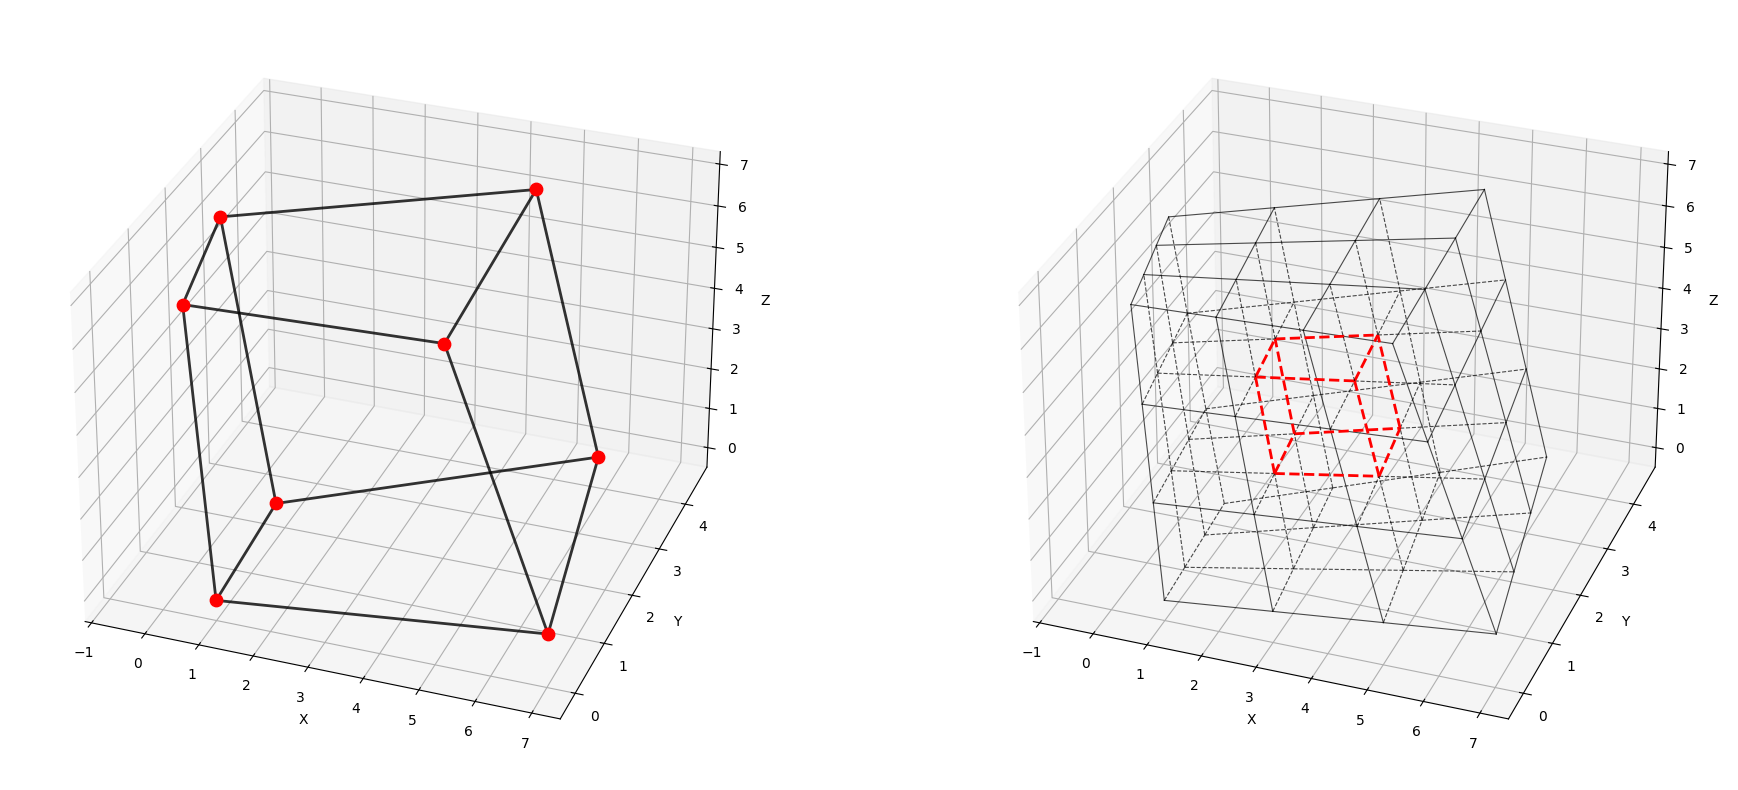

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def trilinear_interpolation(p000, p001, p010, p011, p100, p101, p110, p111, u, v, w):
    return (1-u)*(1-v)*(1-w)*p000 + (1-u)*(1-v)*w*p001 + \
           (1-u)*v*(1-w)*p010 + (1-u)*v*w*p011 + \
           u*(1-v)*(1-w)*p100 + u*(1-v)*w*p101 + \
           u*v*(1-w)*p110 + u*v*w*p111

# 原始顶点
vertices = {
    (0,0,0): np.array([1.000, 0.000, 0.000]),
    (0,0,1): np.array([0.000, 0.777, 6.000]),
    (0,1,0): np.array([0.839, 2.000, 0.072]),
    (0,1,1): np.array([-0.619, 2.768, 5.979]),
    (1,0,0): np.array([7.000, 0.000, 0.798]),
    (1,0,1): np.array([5.000, 0.245, 6.796]),
    (1,1,0): np.array([5.839, 4.000, 0.285]),
    (1,1,1): np.array([4.381, 4.356, 6.202])
}

# === 创建图形和子图 ===
fig = plt.figure(figsize=(20, 8))

# 左子图：原始网格
ax_original = fig.add_subplot(121, projection='3d')
ax_original.view_init(elev=30, azim=-70)

# 右子图：细分网格
ax_subdivided = fig.add_subplot(122, projection='3d')
ax_subdivided.view_init(elev=30, azim=-70)

# ================================================
# 左子图：绘制原始六面体网格
# ================================================
# 提取所有顶点坐标
orig_points = list(vertices.values())

# 定义原始六面体的12条边（连接8个顶点）
orig_edges = [
    # u方向边（x方向）
    ((0,0,0), (1,0,0)),  # 底面前边
    ((0,0,1), (1,0,1)),  # 底面后边
    ((0,1,0), (1,1,0)),  # 顶面前边
    ((0,1,1), (1,1,1)),  # 顶面后边
    
    # v方向边（y方向）
    ((0,0,0), (0,1,0)),  # 前面左边
    ((1,0,0), (1,1,0)),  # 前面右边
    ((0,0,1), (0,1,1)),  # 后面左边
    ((1,0,1), (1,1,1)),  # 后面右边
    
    # w方向边（z方向）
    ((0,0,0), (0,0,1)),  # 底面左边
    ((1,0,0), (1,0,1)),  # 底面右边
    ((0,1,0), (0,1,1)),  # 顶面左边
    ((1,1,0), (1,1,1))   # 顶面右边
]

# 绘制原始六面体的边
for start, end in orig_edges:
    p1 = vertices[start]
    p2 = vertices[end]
    ax_original.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
                    color='black', linewidth=2.0, alpha=0.8)

# 标记原始顶点
for idx, (coord, pt) in enumerate(vertices.items()):
    ax_original.scatter(pt[0], pt[1], pt[2], color='red', s=80, zorder=5)
    # 可以添加顶点标签
    # ax_original.text(pt[0], pt[1], pt[2], f'v{idx}', fontsize=9, 
    #                  verticalalignment='bottom', horizontalalignment='right')

# 设置左子图属性
ax_original.set_title('原始六面体网格', fontsize=14, pad=10)
ax_original.set_xlabel('X')
ax_original.set_ylabel('Y')
ax_original.set_zlabel('Z')
ax_original.grid(True, alpha=0.3)

# ================================================
# 右子图：绘制细分网格（使用你原来的代码逻辑）
# ================================================
# 细分参数
n_u, n_v, n_w = 3, 3, 3
num_u, num_v, num_w = n_u+1, n_v+1, n_w+1

# 生成所有细分点
points = []  # 所有点的坐标列表
index_map = {}  # 逻辑索引到列表索引的映射

for iu in range(num_u):
    u = iu / n_u
    for iv in range(num_v):
        v = iv / n_v
        for iw in range(num_w):
            w = iw / n_w
            pt = trilinear_interpolation(
                vertices[(0,0,0)], vertices[(0,0,1)],
                vertices[(0,1,0)], vertices[(0,1,1)],
                vertices[(1,0,0)], vertices[(1,0,1)],
                vertices[(1,1,0)], vertices[(1,1,1)], u, v, w)
            points.append(pt)
            index_map[(iu, iv, iw)] = len(points)-1

# 收集所有边（避免重复）
edges_to_draw = []

# u方向的边（x方向）
for iv in range(num_v):
    for iw in range(num_w):
        for iu in range(num_u-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu+1, iv, iw)]
            if iv==0 or iw==n_w:
                ax_subdivided.plot([points[idx1][0], points[idx2][0]], 
                                 [points[idx1][1], points[idx2][1]], 
                                 [points[idx1][2], points[idx2][2]], 
                                 color='black', linestyle='-', linewidth=0.8, alpha=0.7)
            else:
                edges_to_draw.append((f'edge_u_{iu}{iv}{iw}_{iu+1}{iv}{iw}', idx1, idx2))

# v方向的边（y方向）
for iu in range(num_u):
    for iw in range(num_w):
        for iv in range(num_v-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu, iv+1, iw)]
            if iu==n_u or iw==n_w:
                ax_subdivided.plot([points[idx1][0], points[idx2][0]], 
                                 [points[idx1][1], points[idx2][1]], 
                                 [points[idx1][2], points[idx2][2]], 
                                 color='black', linestyle='-', linewidth=0.8, alpha=0.7)
            else:
                edges_to_draw.append((f'edge_v_{iu}{iv}{iw}_{iu}{iv+1}{iw}', idx1, idx2))

# w方向的边（z方向）
for iu in range(num_u):
    for iv in range(num_v):
        for iw in range(num_w-1):
            idx1 = index_map[(iu, iv, iw)]
            idx2 = index_map[(iu, iv, iw+1)]
            if iu==n_u or iv==0:
                ax_subdivided.plot([points[idx1][0], points[idx2][0]], 
                                 [points[idx1][1], points[idx2][1]], 
                                 [points[idx1][2], points[idx2][2]], 
                                 color='black', linestyle='-', linewidth=0.8, alpha=0.7)
            else:
                edges_to_draw.append((f'edge_w_{iu}{iv}{iw}_{iu}{iv}{iw+1}', idx1, idx2))

# 绘制剩余的边（你原来需要特殊标记的边）
for edge_name, idx1, idx2 in edges_to_draw:
    p1, p2 = points[idx1], points[idx2]
    
    # 特殊标记的边
    if edge_name in {'edge_u_111_211', 'edge_u_112_212', 'edge_u_122_222', 'edge_u_121_221', 
                     'edge_v_111_121', 'edge_v_211_221', 'edge_v_212_222', 'edge_v_112_122',
                     'edge_w_111_112', 'edge_w_121_122', 'edge_w_211_212', 'edge_w_221_222'}:
        ax_subdivided.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
                          color='red', linestyle='--', linewidth=2.0, alpha=1.0)
    else:
        ax_subdivided.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 
                          color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# 设置右子图属性
ax_subdivided.set_title(f'细分网格 ({n_u}×{n_v}×{n_w} 细分)', fontsize=14, pad=10)
ax_subdivided.set_xlabel('X')
ax_subdivided.set_ylabel('Y')
ax_subdivided.set_zlabel('Z')
ax_subdivided.grid(True, alpha=0.3)

# ================================================
# 统一两个子图的坐标轴范围和视角
# ================================================
# 获取所有点的坐标范围（包括原始和细分）
all_points = list(vertices.values()) + points
all_points_array = np.array(all_points)

# 设置相同的坐标轴范围
x_min, x_max = all_points_array[:, 0].min()-0.5, all_points_array[:, 0].max()+0.5
y_min, y_max = all_points_array[:, 1].min()-0.5, all_points_array[:, 1].max()+0.5
z_min, z_max = all_points_array[:, 2].min()-0.5, all_points_array[:, 2].max()+0.5

for ax in [ax_original, ax_subdivided]:
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])
    ax.set_zlim([z_min, z_max])
    
    # 统一视角
    ax.view_init(elev=30, azim=-70)

# 添加总标题
plt.suptitle('六面体网格细分对比', fontsize=16, y=0.95)

plt.tight_layout()

# 输出统计信息
print(f"原始网格: 8个顶点, 12条边")
print(f"细分网格: {len(points)}个网格点, {len(edges_to_draw)+4*(n_u*n_v+n_u*n_w+n_v*n_w)}条边")
print(f"特殊标记的边: 12条 (红色虚线)")

plt.show()

C:\Users\31717\AppData\Local\Temp\ipykernel_23488\4093545911.py:181: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_23488\4093545911.py:181: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_23488\4093545911.py:181: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_23488\4093545911.py:181: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_23488\4093545911.py:181: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_23488\4093545911.py:181: UserWarning: Glyph 32

原始网格: 8个顶点, 3条边
细分网格: 64个顶点, 81条边
特殊标记的边: 12条 (红色虚线)


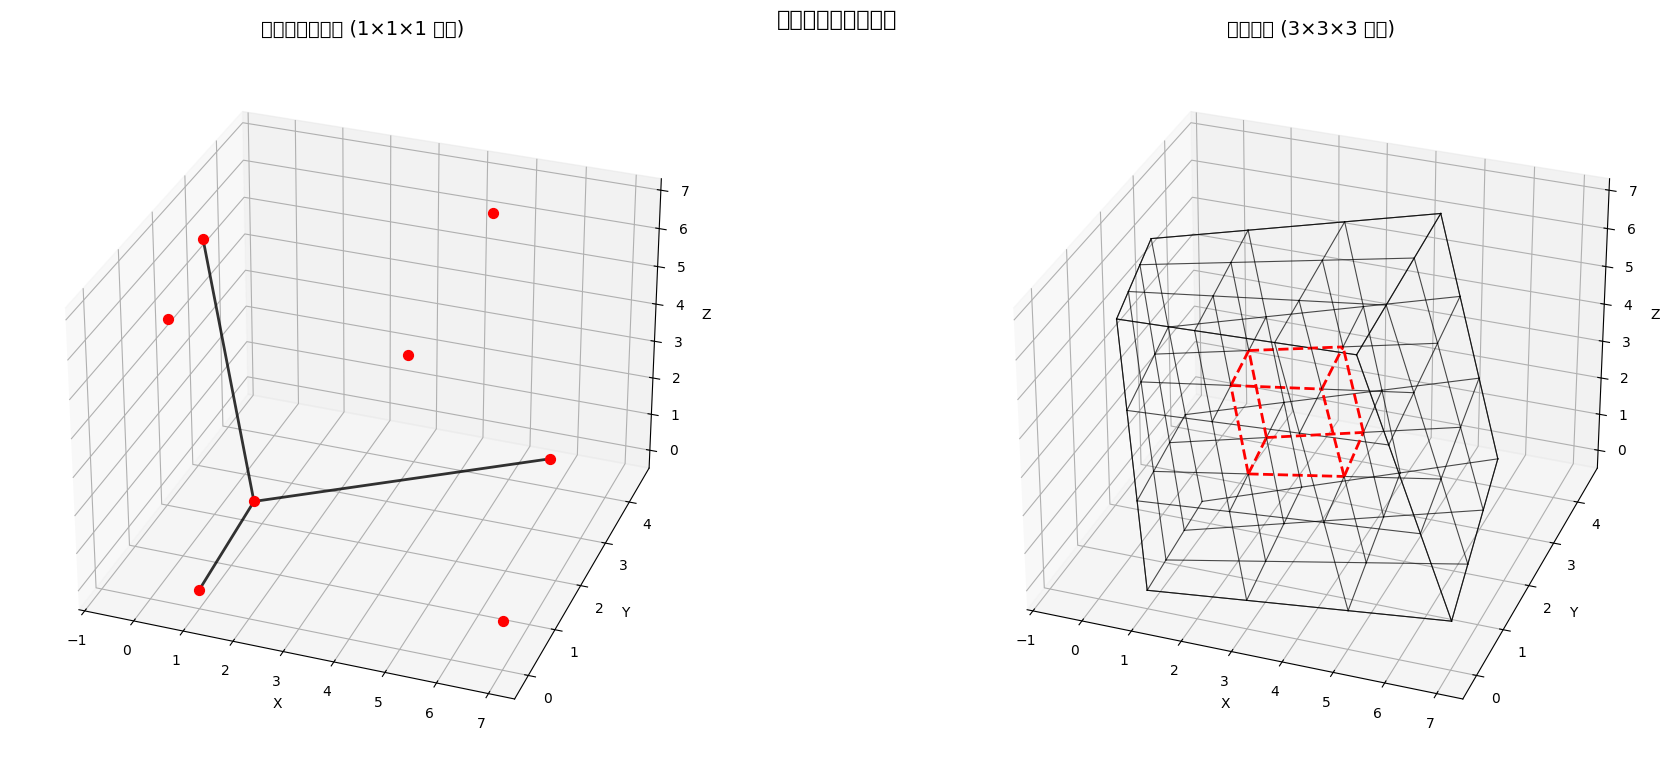